# 1-D CNN: congestion-level classifier

A convolutional neural network that reads one sensor's 2-hour window as a **time series** and predicts next-step
congestion.

**Task (same as `baselines.ipynb` and `train_ann.ipynb`):** given the last 24 × 5-min readings of flow, occupancy and
speed from one sensor, predict whether that sensor's flow in the next 5 minutes will be **Low**, **Medium** or **High**.

**ANN vs CNN:** the ANN flattens the window into 72 numbers and treats every position independently, so it doesn't
know that reading 23 comes right after reading 22. A CNN slides small filters **along time**, so it learns local
patterns (a rise, a drop, a plateau) wherever in the window they occur.

| Step | What happens |
|---|---|
| 1 | Load the preprocessed sequences, shape (24, 3) |
| 2 | Hold out the last 10 % of the training period for validation |
| 3 | Build and train the CNN, with early stopping |
| 4 | Evaluate once on the test set |
| 5 | Compare with the baselines and the ANN, overall and per sensor |
| 6 | Save the model and results |

**Targets to beat:** the 15-min-average rule (≈ 88.1 %) and the ANN (≈ 89.0 %).

## 0 · Setup

In [1]:
import json
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, jaccard_score)

# Paths
PROJECT = os.path.abspath(".")  # run the notebooks from the repository root

DATA_DIR    = os.path.join(PROJECT, "data")
MODELS_DIR  = os.path.join(PROJECT, "models")
RESULTS_DIR = os.path.join(PROJECT, "results")

for folder in (DATA_DIR, MODELS_DIR, RESULTS_DIR):
    os.makedirs(folder, exist_ok=True)


# Config
DATA_FILE        = os.path.join(DATA_DIR, "traffic_flow_preprocessed.npz")
BASELINE_FILE    = os.path.join(RESULTS_DIR, "baseline_results.json")
ANN_FILE         = os.path.join(RESULTS_DIR, "ann_results.json")
MODEL_FILE       = os.path.join(MODELS_DIR, "cnn_model.keras")
RESULTS_FILE     = os.path.join(RESULTS_DIR, "cnn_results.json")
PREDICTIONS_FILE = os.path.join(RESULTS_DIR, "cnn_predictions.npz")

CLASS_NAMES = ["Low", "Medium", "High"]
VAL_FRAC = 0.10          # last 10 % of the training period -> validation
BATCH_SIZE = 1024
EPOCHS = 25
LEARNING_RATE = 1e-3
PATIENCE = 3
SEED = 42

keras.utils.set_random_seed(SEED)

## 1 · Load the data as sequences

Unlike the ANN, the CNN keeps the **sequence shape** `(24, 3)` from `preprocess.ipynb`:
24 timesteps, each with 3 channels (flow, occupancy, speed), already standardised per sensor.
It's the same layout as a 1-D signal with 3 channels, which is what `Conv1D` expects.

> **Why not the old `Conv2D`?** The old notebook fed a 12 × 170 "image" of *all sensors at once*. Each sample is now
> a single sensor, so there's no sensor axis to convolve over. Time is the only axis with structure.

In [2]:
d = np.load(DATA_FILE)
X_train_all, y_train_all = d["X_train_seq"], d["y_train"].astype(np.int32)
X_test, y_test = d["X_test_seq"], d["y_test"].astype(np.int32)
time_train, sensor_test = d["time_train"], d["sensor_test"]

print(f"Train: {X_train_all.shape}   Test: {X_test.shape}   (samples, timesteps, channels)")

Train: (2425050, 24, 3)   Test: (606390, 24, 3)   (samples, timesteps, channels)


## 2 · Validation split from the end of the training period

Same as in the ANN notebook: the **latest 10 %** of the training timeline is used for validation, which early stopping
relies on. The old notebook used `validation_split=0.2`, which also takes the last part of the data. That was fine, but
it had no early stopping, so it simply returned whatever epoch 20 produced (its validation accuracy swung between 83 % and 94 %).

```
|——————— fit (≈ 72 %) ———————|— val (≈ 8 %) —|——— test (20 %) ———|
```

In [3]:
val_start = np.quantile(time_train, 1 - VAL_FRAC)
is_val = time_train >= val_start

X_fit, y_fit = X_train_all[~is_val], y_train_all[~is_val]
X_val, y_val = X_train_all[is_val], y_train_all[is_val]

print(f"Fit: {len(X_fit):,}   Validation: {len(X_val):,}   Test: {len(X_test):,}")

Fit: 2,182,460   Validation: 242,590   Test: 606,390


## 3 · Model

```
input (24, 3)
→ Conv1D 32 → Conv1D 32 → MaxPool     (24 → 12 steps)   short patterns, ~15 min
→ Conv1D 64 → MaxPool                 (12 → 6 steps)    longer patterns, ~30–60 min
→ Conv1D 128                                             whole-window patterns
→ Global average pooling → Dense 128 → Dropout 0.3 → Dense 3 (softmax)
```

* **Conv1D (kernel size 3):** each filter looks at 3 consecutive readings (15 minutes) across all 3 channels, and slides
  along the window. Stacking layers widens what each filter "sees".
* **MaxPooling1D:** halves the time length, keeping the strongest response in each pair of steps. Later layers then
  cover a longer stretch of time.
* **Global average pooling:** averages each of the 128 filter outputs over time, giving one number per filter.
  This replaces the old `Flatten`, which created a 16,128-wide layer and 2 million weights. The model is now about
  51k parameters and much less prone to overfitting.
* **Dropout 0.3 → softmax:** same classification head as the ANN.

In [4]:
model = keras.Sequential([
    layers.Input(shape=X_fit.shape[1:]),
    layers.Conv1D(32, 3, padding="same", activation="relu"),
    layers.Conv1D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax"),
], name="cnn_1d")

model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "cnn_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 32)         │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,235 (200.14 KB)

 Trainable params: 51,235 (200.14 KB)

 Non-trainable params: 0 (0.00 B)

## 4 · Train

Early stopping watches validation loss and restores the best epoch's weights. Expect about 1 minute per epoch on a
laptop CPU.

In [5]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                           restore_best_weights=True)
history = model.fit(X_fit, y_fit,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=[early_stop], verbose=1)

best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"\nStopped after {len(history.history['loss'])} epochs; best epoch = {best_epoch}")

Epoch 1/25
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8660 - loss: 0.3123 - val_accuracy: 0.8756 - val_loss: 0.2800
Epoch 2/25
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8754 - loss: 0.2862 - val_accuracy: 0.8787 - val_loss: 0.2727
Epoch 3/25
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8777 - loss: 0.2800 - val_accuracy: 0.8813 - val_loss: 0.2677
Epoch 4/25
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8801 - loss: 0.2743 - val_accuracy: 0.8837 - val_loss: 0.2623
Epoch 5/25
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8823 - loss: 0.2695 - val_accuracy: 0.8853 - val_loss: 0.2584
Epoch 6/25
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8839 - loss: 0.2660 - val_accuracy: 0.8858 - val_loss: 0.2581
Epoch 7/25
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.8848 - loss: 0.2637 - val_accuracy: 0.8872 - val_loss: 0.2549
Epoch 8/25
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8855 -

### Training curves

Train and validation curves should stay close. A widening gap would mean overfitting.

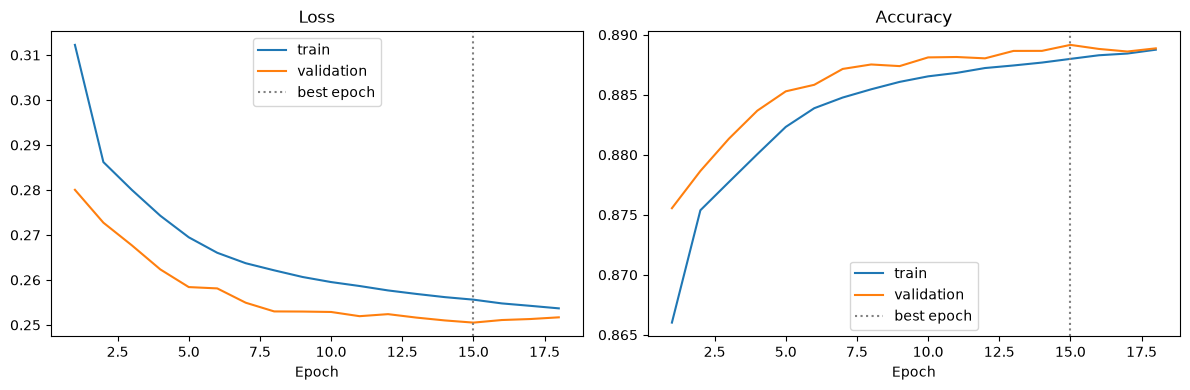

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key in zip(axes, ["loss", "accuracy"]):
    epochs = range(1, len(history.history[key]) + 1)
    ax.plot(epochs, history.history[key], label="train")
    ax.plot(epochs, history.history[f"val_{key}"], label="validation")
    ax.axvline(best_epoch, color="gray", ls=":", label="best epoch")
    ax.set_xlabel("Epoch"); ax.set_title(key.capitalize()); ax.legend()
fig.tight_layout()
plt.show()

## 5 · Evaluate on the test set

Same metrics as the ANN: accuracy, macro-F1 (all three classes weighted equally) and per-class IoU.

In [7]:
y_prob = model.predict(X_test, batch_size=8192, verbose=0)
y_pred = y_prob.argmax(axis=1).astype(np.int32)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
iou = jaccard_score(y_test, y_pred, average=None)

print(f"CNN test accuracy: {acc:.4f}   macro-F1: {macro_f1:.4f}   mean IoU: {iou.mean():.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))
for name, v in zip(CLASS_NAMES, iou):
    print(f"IoU {name:<7}: {v:.4f}")

CNN test accuracy: 0.8918   macro-F1: 0.8911   mean IoU: 0.8073

              precision    recall  f1-score   support

         Low     0.9561    0.9540    0.9551    204308
      Medium     0.8418    0.8258    0.8338    198136
        High     0.8756    0.8937    0.8846    203946

    accuracy                         0.8918    606390
   macro avg     0.8912    0.8912    0.8911    606390
weighted avg     0.8917    0.8918    0.8917    606390

IoU Low    : 0.9140
IoU Medium : 0.7149
IoU High   : 0.7930


### Confusion matrix

Rows are the true class, columns the prediction, shown as row percentages. Errors should sit next to the diagonal.

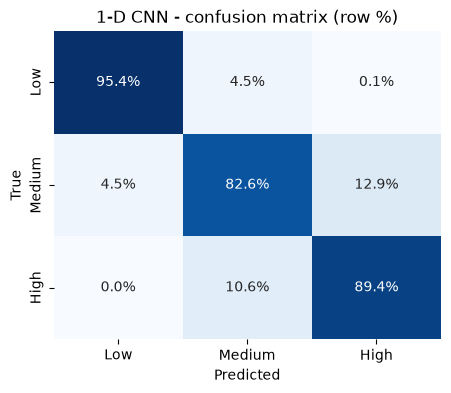

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".1%", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("1-D CNN - confusion matrix (row %)")
plt.show()

## 6 · Comparison with the baselines and the ANN

Scores come from `baseline_results.json` and `ann_results.json`, all on the same test set.

In [9]:
with open(BASELINE_FILE) as f:
    results = json.load(f)
if os.path.exists(ANN_FILE):
    with open(ANN_FILE) as f:
        ann = json.load(f)
    results["ANN"] = {"accuracy": ann["accuracy"], "macro_f1": ann["macro_f1"]}
results["1-D CNN"] = {"accuracy": float(acc), "macro_f1": float(macro_f1)}

table = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
display(table.style.format("{:.4f}"))

best_baseline = table.drop(index=[i for i in ["ANN", "1-D CNN"] if i in table.index])["accuracy"].idxmax()
print(f"CNN vs best baseline ({best_baseline}): {(acc - table.loc[best_baseline, 'accuracy']) * 100:+.2f} points")
if "ANN" in table.index:
    print(f"CNN vs ANN: {(acc - table.loc['ANN', 'accuracy']) * 100:+.2f} points")

,accuracy,macro_f1
1-D CNN,0.8918,0.8911
ANN,0.8899,0.8893
15-min average,0.8808,0.8804
Persistence,0.8728,0.8721
Logistic regression,0.8724,0.8717
Linear trend,0.8066,0.8043
Majority class,0.3363,0.1678


CNN vs best baseline (15-min average): +1.11 points
CNN vs ANN: +0.20 points


### Per-sensor comparison

Each dot is one sensor. Points above the diagonal are sensors where the CNN beats the 15-min-average rule.
The rule is recomputed from the test inputs, after undoing the per-sensor standardisation of flow.

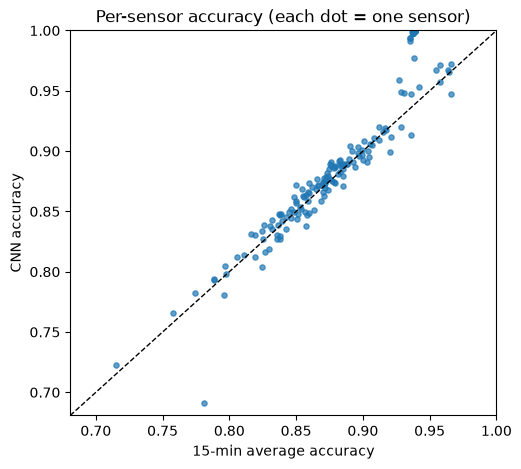

CNN is better on 121 of 170 sensors
Largest gains : {124: 0.062, 48: 0.061, 61: 0.061}
Largest losses: {155: -0.09, 160: -0.022, 78: -0.021}


In [10]:
mean, std, low_th, high_th = d["feature_mean"], d["feature_std"], d["low_th"], d["high_th"]
flow = X_test[:, -3:, 0] * std[sensor_test, 0][:, None] + mean[sensor_test, 0][:, None]
avg15 = flow.mean(axis=1)
lo, hi = low_th[sensor_test], high_th[sensor_test]
y_base = np.where(avg15 <= lo, 0, np.where(avg15 <= hi, 1, 2))

per_sensor = pd.DataFrame({"sensor": sensor_test,
                           "cnn": y_pred == y_test,
                           "baseline": y_base == y_test}).groupby("sensor").mean()

plt.figure(figsize=(5.5, 5))
plt.scatter(per_sensor["baseline"], per_sensor["cnn"], s=14, alpha=0.7)
lims = [per_sensor.values.min() - 0.01, 1.0]
plt.plot(lims, lims, "k--", lw=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("15-min average accuracy"); plt.ylabel("CNN accuracy")
plt.title("Per-sensor accuracy (each dot = one sensor)")
plt.show()

diff = per_sensor["cnn"] - per_sensor["baseline"]
print(f"CNN is better on {(diff > 0).sum()} of {len(per_sensor)} sensors")
print(f"Largest gains : {diff.nlargest(3).round(3).to_dict()}")
print(f"Largest losses: {diff.nsmallest(3).round(3).to_dict()}")

### What the results mean

* **The CNN is the best model so far, but only just.** 89.2 %, which is +1.2 points over the 15-min-average rule and
  +0.2 over the ANN. Reading the window as a time series helps a little. Most of the next 5 minutes is still predicted
  by "traffic stays about the same", so the room left for any model is small.
* **It beats the baseline on 120 of 170 sensors** (the ANN managed 115), with gains of up to about 6 points on busy,
  regular sensors.
* **Sensor 155 is again the weakest (−7 points, vs −11 for the ANN).** Its traffic rose by about 58 % in the test period,
  so its test data looks unlike its training data. The CNN copes a little better than the ANN.
* **Medium remains the hardest class** (F1 ≈ 0.84), because it has a threshold on both sides.
* **Training stopped at the 25-epoch limit, not by early stopping.** Validation loss was still creeping down, so raising
  `EPOCHS` might add roughly another 0.1 point, at about 1 minute per extra epoch.

## 7 · Example predictions

Ten random test samples with the CNN's class probabilities. Confident, correct predictions put about 1.0 on one class.
Samples near a threshold split probability between two neighbouring classes.

In [11]:
rng = np.random.default_rng(SEED)
idx = np.sort(rng.choice(len(y_test), size=10, replace=False))
pd.DataFrame({
    "sensor": sensor_test[idx],
    "true": [CLASS_NAMES[i] for i in y_test[idx]],
    "predicted": [CLASS_NAMES[i] for i in y_pred[idx]],
    "P(Low)": y_prob[idx, 0].round(3),
    "P(Medium)": y_prob[idx, 1].round(3),
    "P(High)": y_prob[idx, 2].round(3),
})

,sensor,true,predicted,P(Low),P(Medium),P(High)
0,96,Medium,Medium,0.001,0.672,0.326
1,60,High,High,0.000,0.000,1.000
2,158,High,Medium,0.007,0.836,0.157
3,108,Low,Low,1.000,0.000,0.000
4,93,Low,Low,0.997,0.003,0.000
5,78,Low,Low,0.995,0.005,0.000
6,141,High,High,0.000,0.000,1.000
7,85,Low,Low,1.000,0.000,0.000
8,113,Low,Low,0.998,0.002,0.000
9,101,High,High,0.000,0.163,0.837


## 8 · Save

* `cnn_model.keras`: the trained network.
* `cnn_results.json`: the scores, same format as the ANN and baselines, for the final comparison.
* `cnn_predictions.npz`: test predictions, probabilities and the training history.

In [12]:
model.save(MODEL_FILE)
with open(RESULTS_FILE, "w") as f:
    json.dump({"accuracy": float(acc), "macro_f1": float(macro_f1),
               "iou_per_class": iou.tolist(), "mean_iou": float(iou.mean()),
               "best_epoch": best_epoch}, f, indent=2)
np.savez(PREDICTIONS_FILE, y_true=y_test, y_pred=y_pred, y_prob=y_prob, sensor=sensor_test,
         **{f"history_{k}": np.array(v) for k, v in history.history.items()})
print(f"Saved {MODEL_FILE}, {RESULTS_FILE}, {PREDICTIONS_FILE}")

Saved E:\Traffic Flow Detection Using Neural Networks\models\cnn_model.keras, E:\Traffic Flow Detection Using Neural Networks\results\cnn_results.json, E:\Traffic Flow Detection Using Neural Networks\results\cnn_predictions.npz
